In [274]:
from IPython.display import Markdown as md

In [275]:
import pandas as pd
import numpy as np
from utils import (
    convert_to_numeric,
    split_dict_columns,
    get_tot_results_compare,
    compare_unique_solved_instances,
    build_markdown_comparison_matrix,
    copy_instances,
    plot_performance_profiles,
    plot_time_histogram,
    query_time,
    SolverResult,
    SOPLEX,
    GLPK,
    QSOPTEX,
)

In [276]:
DROP_UNSOLVED = True

In [277]:
all_instances = pd.read_csv("../instances.csv").set_index("file")
all_instances

""
file
0003-labyrinth-11-0.smt2
0011-labyrinth-12-0.smt2
0018-labyrinth-11-0.smt2
0028-labyrinth-12-0.smt2
0036-labyrinth-17-0.smt2
...
yPositive-SIscaled75.bpl_Iteration1_Loop_3-pieceTemplate.smt2
yPositive-SIscaled75.bpl_Iteration1_Loop_4-phaseTemplate.smt2
yPositive-SIscaled75.bpl_Iteration1_Loop_4-pieceTemplate.smt2


In [278]:
soplex_i100 = pd.read_csv("../soplex_i100.csv").set_index("file")
soplex_i100 = soplex_i100[soplex_i100["resultS"].isin(["sat", "unsat"])] if DROP_UNSOLVED else soplex_i100
soplex_i100

,options::pivots,options::checkModels,build,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,...,theory::arith::z::approx::refinements,theory::arith::z::arith::relax::calls,theory::arith::z::arith::relax::exhausted,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,resultS,timeS
file,,,,,,,,,,,,,,,,,,,,,
sin-problem-7-weak-chunk-0022.smt2,100,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,30ms,...,NaN,0,0,0,0,0,0,0,sat,0.030
Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_7-phaseTemplate.smt2,100,0,production,0,0,67278,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Brave...,1062264ms,...,"{ 2: 24, 3: 109, 4: 47 }",180,0,0,126,54,54,0,unsat,1062.264
constraints-cooking12.smt2,100,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,56ms,...,NaN,0,0,0,0,0,0,0,sat,0.056
sc-13.induction3.cvc.smt2,100,0,production,1,1,3249,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-13...,247ms,...,NaN,0,0,0,0,0,0,0,sat,0.247
sc-6.induction.cvc.smt2,100,0,production,1,1,470,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-6....,69ms,...,NaN,0,0,0,0,0,0,0,sat,0.069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Chua-2-IL-L-chunk-0066.smt2,100,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Chua-...,44ms,...,NaN,0,0,0,0,0,0,0,sat,0.044
19.smt2,100,0,production,1,1,120,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/19.smt2,80ms,...,NaN,0,0,0,0,0,0,0,sat,0.080
_overflow1.i_3_8_2.bpl_11.smt2,100,0,production,0,0,2558290,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/_over...,6088207ms,...,"{ 1: 1, 11: 1, 2: 1, 3: 12, 4: 35, 5: 17, 6: 5...",105,0,0,70,35,0,0,unsat,6088.207


In [279]:
soplex_i10 = pd.read_csv("../soplex_i10.csv").set_index("file")
soplex_i10 = soplex_i10[soplex_i10["resultS"].isin(["sat", "unsat"])] if DROP_UNSOLVED else soplex_i10
soplex_i10

,options::pivots,options::checkModels,build,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,...,theory::arith::z::approx::refinements,theory::arith::z::arith::relax::calls,theory::arith::z::arith::relax::exhausted,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,resultS,timeS
file,,,,,,,,,,,,,,,,,,,,,
sin-problem-7-weak-chunk-0022.smt2,10,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,38ms,...,NaN,0,0,0,0,0,0,0,sat,0.038
constraints-cooking12.smt2,10,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,55ms,...,{ 0: 1 },1,0,0,1,0,0,0,sat,0.055
sc-13.induction3.cvc.smt2,10,0,production,1,1,3249,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-13...,201ms,...,NaN,0,0,0,0,0,0,0,sat,0.201
sin-problem-7-weak-chunk-0007.smt2,10,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,30ms,...,NaN,0,0,0,0,0,0,0,sat,0.030
sin-problem-7-weak-chunk-0095.smt2,10,0,production,0,0,0,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,37ms,...,NaN,0,0,0,0,0,0,0,unsat,0.037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sc-23.base.cvc.smt2,10,0,production,0,0,69061,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-23...,2255511ms,...,"{ 0: 16, 1: 1127, 2: 31095, 3: 6201, 4: 2392, ...",41573,0,0,1172,40401,40393,0,unsat,2255.511
sin-problem-7-chunk-0006.smt2,10,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,37ms,...,NaN,0,0,0,0,0,0,0,sat,0.037
Chua-2-IL-L-chunk-0066.smt2,10,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Chua-...,45ms,...,NaN,0,0,0,0,0,0,0,sat,0.045


In [280]:
soplex_i200 = pd.read_csv("../soplex_i200.csv").set_index("file")
soplex_i200 = soplex_i200[soplex_i200["resultS"].isin(["sat", "unsat"])] if DROP_UNSOLVED else soplex_i200
soplex_i200

,options::pivots,options::checkModels,build,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,...,theory::arith::z::approx::refinements,theory::arith::z::arith::relax::calls,theory::arith::z::arith::relax::exhausted,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,resultS,timeS
file,,,,,,,,,,,,,,,,,,,,,
sin-problem-7-weak-chunk-0022.smt2,200,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,33ms,...,NaN,0,0,0,0,0,0,0,sat,0.033
Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_7-phaseTemplate.smt2,200,0,NaN,0,0,87590,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Brave...,1627910ms,...,"{ 2: 2, 3: 12, 4: 3 }",17,0,0,14,3,3,0,unsat,1627.910
constraints-cooking12.smt2,200,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,40ms,...,NaN,0,0,0,0,0,0,0,sat,0.040
sc-13.induction3.cvc.smt2,200,0,production,1,1,3249,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-13...,234ms,...,NaN,0,0,0,0,0,0,0,sat,0.234
sas2.t2.c_Iteration3_Lasso_6-phaseTemplate.smt2,200,0,NaN,1,1,181030,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sas2....,23508ms,...,NaN,0,0,0,0,0,0,0,sat,23.508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Chua-2-IL-L-chunk-0066.smt2,200,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Chua-...,44ms,...,NaN,0,0,0,0,0,0,0,sat,0.044
19.smt2,200,0,production,1,1,120,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/19.smt2,105ms,...,NaN,0,0,0,0,0,0,0,sat,0.105
_overflow1.i_3_8_2.bpl_11.smt2,200,0,NaN,0,0,3023801,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/_over...,6831933ms,...,{ 5: 1 },1,0,0,1,0,0,0,unsat,6831.933


In [281]:
def sanitize(df: pd.DataFrame):
    for col in df.columns:
        df[col] = df[col].apply(convert_to_numeric)

    df["theory::arith::z::approx::externalSimplexType"] = df["theory::arith::z::approx::externalSimplexType"].astype("category")
    precision_df = df["theory::arith::z::approx::precision"].apply(lambda x: split_dict_columns(x, "precision"))
    refinements = df["theory::arith::z::approx::refinements"].apply(lambda x: split_dict_columns(x, "refinements"))
    return pd.concat([df, precision_df, refinements], axis=1)

soplex_i10 = sanitize(soplex_i10)
soplex_i100 = sanitize(soplex_i100)
soplex_i200 = sanitize(soplex_i200)

In [282]:
# All instances with at least a call to the external simplex should have a value for the external simplex type
def check_external_simplex_calls(df: pd.DataFrame):
    assert len(df[(df["theory::arith::z::arith::relax::calls"] > 0) & (df["theory::arith::z::approx::externalSimplexType"].isna())]) == 0
    assert len(df[df["theory::arith::z::approx::externalSimplexType"].notna()]) == len(df[(df["theory::arith::z::arith::relax::calls"] > 0)])
    assert all(df[df["theory::arith::z::approx::externalSimplexType"].notna()]["theory::arith::z::approx::externalSimplexType"] == SOPLEX)
check_external_simplex_calls(soplex_i10)
check_external_simplex_calls(soplex_i100)
check_external_simplex_calls(soplex_i200)

In [283]:
INTERESTING_COLS = [
    "global::totalTime",
    "theory::arith::z::arith::relax::calls",
    "theory::arith::z::approx::lp::setup::timer",
    "theory::arith::z::approx::lp::timer",
    "theory::arith::z::arith::relax::infeasible::failures",
    "theory::arith::z::approx::precision",
    "theory::arith::z::approx::refinements",
    "theory::arith::attempt::extendedSearch",
    "resultS"
]

In [284]:
soplex_i10.loc["ecoliMILPglycerolYices3-60000.smt2"][INTERESTING_COLS]

global::totalTime                                            12967
theory::arith::z::arith::relax::calls                           49
theory::arith::z::approx::lp::setup::timer                     811
theory::arith::z::approx::lp::timer                           4627
theory::arith::z::arith::relax::infeasible::failures             0
theory::arith::z::approx::precision                     { 64: 49 }
theory::arith::z::approx::refinements                    { 2: 49 }
theory::arith::attempt::extendedSearch                          12
resultS                                                        sat
Name: ecoliMILPglycerolYices3-60000.smt2, dtype: object

In [285]:
soplex_i100.loc["ecoliMILPglycerolYices3-60000.smt2"][INTERESTING_COLS]

global::totalTime                                            18419
theory::arith::z::arith::relax::calls                           41
theory::arith::z::approx::lp::setup::timer                     678
theory::arith::z::approx::lp::timer                           3787
theory::arith::z::arith::relax::infeasible::failures             1
theory::arith::z::approx::precision                     { 64: 41 }
theory::arith::z::approx::refinements                    { 2: 41 }
theory::arith::attempt::extendedSearch                           9
resultS                                                        sat
Name: ecoliMILPglycerolYices3-60000.smt2, dtype: object

In [286]:
soplex_i200.loc["ecoliMILPglycerolYices3-60000.smt2"][INTERESTING_COLS]

global::totalTime                                            15762
theory::arith::z::arith::relax::calls                           39
theory::arith::z::approx::lp::setup::timer                     417
theory::arith::z::approx::lp::timer                           3039
theory::arith::z::arith::relax::infeasible::failures             0
theory::arith::z::approx::precision                     { 64: 39 }
theory::arith::z::approx::refinements                    { 2: 39 }
theory::arith::attempt::extendedSearch                           9
resultS                                                        sat
Name: ecoliMILPglycerolYices3-60000.smt2, dtype: object

# Benchmarks

We are using the [SMT-LIB](https://smt-lib.org/benchmarks.shtml) benchmarks for our evaluation.

To be precise, we are using the [QF_LRA](https://smt-lib.org/logics-all.shtml#QF_LRA) theory benchmarks from the [SMT-LIB release 2025 of non-incremental benchmarks](https://zenodo.org/records/16740866).
The set is composed of 1753 instances.
We ran with a timeout of 6 hours (?) and a memory limit of 4GB.
We used the Comet HPC cluster from Newcastle University.
Each node uses an AMD EPYC 9745 @ 2.4 GHz 128-core processor (256 threads), although we only used one core per instance.

### Hardware details

| CPU           | Architecture | Frequency | Turbo frequency | Cores | Memory | L1      | L2        | L3     | Time limit |
| ------------- | ------------ | --------- | --------------- | ----- | ------ | ------- | --------- | ------ | ---------- |
| AMD EPYC 9745 | x86_64       | 2.4 GHz   | 3.7 GHz         | 1     | 4GB    | 6144 KB | 131072 KB | 256 MB | 6 hours    |

In [287]:
# Number of instances solved in total
def get_tot_results(df: pd.DataFrame) -> int:
    assert len(df["options::pivots"].unique()) > 0
    tot = 1753
    table_entries_by_pivot = []
    for pivots in df["options::pivots"].unique():
        sub_df = df[df["options::pivots"] == pivots]
        solved = len(sub_df)
        not_external = len(sub_df[sub_df["theory::arith::z::arith::relax::calls"] == 0])
        external = len(sub_df[sub_df["theory::arith::z::arith::relax::calls"] > 0])
        assert solved == not_external + external
        entry =  f"| **QF_LRA** | {pivots}             | {tot}               | {solved}         | {tot - solved}     | {external}                            | {not_external}                           | 0      |"
        table_entries_by_pivot.append(entry)
        table_rows = "\n".join(table_entries_by_pivot)
    return f"""
### Benchmarks details
    
| Theory     | Rational pivot limit | Number of instances | Solved instances | Unsolved instances | Instances with external simplex calls | Instances without external simplex calls | Errors |
| ---------- | -------------------- | ------------------- | ---------------- | ------------------ | ------------------------------------- | ---------------------------------------- | ------ |
{table_rows}
"""
md(get_tot_results(pd.concat([soplex_i10, soplex_i100, soplex_i200])))


### Benchmarks details

| Theory     | Rational pivot limit | Number of instances | Solved instances | Unsolved instances | Instances with external simplex calls | Instances without external simplex calls | Errors |
| ---------- | -------------------- | ------------------- | ---------------- | ------------------ | ------------------------------------- | ---------------------------------------- | ------ |
| **QF_LRA** | 10             | 1753               | 1111         | 642     | 467                            | 644                           | 0      |
| **QF_LRA** | 100             | 1753               | 1580         | 173     | 208                            | 1372                           | 0      |
| **QF_LRA** | 200             | 1753               | 1687         | 66     | 122                            | 1565                           | 0      |


In [288]:
solver_inputs = [
    SolverResult(soplex_i10, "SoPlex (10 pivots)", "S"),
    SolverResult(soplex_i100, "SoPlex (100 pivots)", "S"),
    SolverResult(soplex_i200, "SoPlex (200 pivots)", "S"),
]

pairwise_only = compare_unique_solved_instances(*solver_inputs)
solver_order = [solver.solver_name for solver in solver_inputs]

md(build_markdown_comparison_matrix(pairwise_only, solver_order))

### Pairwise matrix (instances solved by row solver but not by column solver)
| Solver A \ Solver B | SoPlex (10 pivots) | SoPlex (100 pivots) | SoPlex (200 pivots) |
| --- | --- | --- | --- |
| SoPlex (10 pivots) |  | 10 | 1 |
| SoPlex (100 pivots) | 479 |  | 1 |
| SoPlex (200 pivots) | 577 | 108 |  |

In [289]:
merged = pd.merge(soplex_i10, soplex_i100, left_index=True, right_index=True, suffixes=("_i10", "_i100"))
merged = merged[["global::totalTime_i10", "global::totalTime_i100"]]
merged

,global::totalTime_i10,global::totalTime_i100
file,,
sin-problem-7-weak-chunk-0022.smt2,38,30
constraints-cooking12.smt2,55,56
sc-13.induction3.cvc.smt2,201,247
sin-problem-7-weak-chunk-0007.smt2,30,25
sin-problem-7-weak-chunk-0095.smt2,37,28
...,...,...
sc-23.base.cvc.smt2,2255511,11552
sin-problem-7-chunk-0006.smt2,37,34
Chua-2-IL-L-chunk-0066.smt2,45,44


In [290]:
diffs = pd.DataFrame(merged["global::totalTime_i10"] - merged["global::totalTime_i100"], columns=["time_diff"])
diffs["winner"] = diffs.time_diff.apply(lambda x: "i10" if x < 0 else ("i100" if x > 0 else "tie"))
diffs

min_diff = 10 * 1000
min_diffs = diffs[diffs["time_diff"].abs() > min_diff]
min_diffs["winner"].value_counts()
min_diffs[min_diffs["winner"] == "i10"]

,time_diff,winner
file,,
ecoliMILPglycerolYices3-80000.smt2,-11430,i10
0075-labyrinth-13-0.smt2,-70550,i10
danoint-266.smt2,-188267,i10
wrong_loop.t2.c_Iteration3_Loop_7-phaseTemplate.smt2,-15360,i10
pp08a-5000.smt2,-189819,i10
rand_80_340_1159656267_0.lp.smt2,-38070,i10


In [291]:
external = soplex_i100[soplex_i100["theory::arith::z::arith::relax::calls"] > 0]
external.sort_values("global::totalTime", inplace=True)
external[["global::totalTime", "theory::arith::z::arith::relax::calls", "theory::arith::z::approx::externalSimplexType","resultS"]].head(20)

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::externalSimplexType,resultS
file,,,,
constraints-cooking13.smt2,54,1,2.0,sat
constraints-cooking19.smt2,55,1,2.0,sat
constraints-cooking20.smt2,60,1,2.0,sat
constraints-cooking16.smt2,60,1,2.0,sat
constraints-cooking14.smt2,63,1,2.0,sat
constraints-tms-2-3-light-30.smt2,67,1,2.0,sat
constraints-tms-2-3-light-20.smt2,70,1,2.0,sat
constraints-cooking21.smt2,70,1,2.0,sat
constraints-tempo-depth-30.smt2,78,1,2.0,sat


### Comparison with other solvers

We aim to compare our implementation with other state-of-the-art SMT solvers, such as [Z3](https://github.com/Z3Prover/z3) and [Yices](https://yices.csl.sri.com/), as well as the baseline version of [cvc5](https://cvc5.github.io/), using both the rational simplex implementation and the approximate one via [GLPK](https://www.gnu.org/software/glpk/).

In [292]:
yices = pd.read_csv("../yices.csv").dropna(subset=["resultY"]).set_index("file")
# Drop rows where the result is not SAT or UNSAT (i.e. where the solver did not solve the instance)
yices = yices[yices["resultY"].isin(["sat", "unsat"])] if DROP_UNSOLVED else yices
md(get_tot_results_compare(SolverResult(soplex_i100, "SoPlex", "S"), SolverResult(yices, "Yices", "Y")))


#### Yices comparison with SoPlex

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | SoPlex only     | Yices only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 1724         | 29       | 0 | 1571    | 9 | 153 |


In [293]:
z3 = pd.read_csv("../z3.csv").dropna(subset=["resultZ"]).set_index("file")
z3 = z3[z3["resultZ"].isin(["sat", "unsat"])] if DROP_UNSOLVED else z3
md(get_tot_results_compare(SolverResult(soplex_i100, "SoPlex", "S"), SolverResult(z3, "Z3", "Z")))


#### Z3 comparison with SoPlex

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | SoPlex only     | Z3 only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 1691         | 62       | 0 | 1555    | 25 | 136 |


In [294]:
cvc5 = pd.read_csv("../cvc5.csv").dropna(subset=["resultC"]).set_index("file")
cvc5 = cvc5[cvc5["resultC"].isin(["sat", "unsat"])] if DROP_UNSOLVED else cvc5
md(get_tot_results_compare(SolverResult(soplex_i100, "SoPlex", "S"), SolverResult(cvc5, "cvc5", "C")))


#### cvc5 comparison with SoPlex

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | SoPlex only     | cvc5 only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 1713         | 40       | 0 | 1570    | 10 | 143 |


In [295]:
glpk = pd.read_csv("../glpk_i200.csv").dropna(subset=["resultG"]).set_index("file")
glpk = glpk[glpk["resultG"].isin(["sat", "unsat"])] if DROP_UNSOLVED else glpk
md(get_tot_results_compare(SolverResult(soplex_i100, "SoPlex", "S"), SolverResult(glpk, "GLPK", "G")))


#### GLPK comparison with SoPlex

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | SoPlex only     | GLPK only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 1678         | 75       | 0 | 1578    | 2 | 100 |


In [296]:
glpk[glpk["theory::arith::z::arith::relax::calls"] > 0]

,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,preprocessing::theory-preprocess,sat::clauses_literals,sat::conflicts,...,theory::arith::z::arith::relax::exhausted,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,options::pivots,options::checkModels,resultG,timeG
file,,,,,,,,,,,,,,,,,,,,,
constraints-temporal-machine-shop-2-3-A40.smt2,1,1,657,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,204ms,4ms,2788,0,...,0,0,1,0,0,0,NaN,NaN,sat,0.204
constraints-tempo-matrix7x7.pddl.smt2,1,1,30757,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,762ms,20ms,6656,0,...,0,0,1,0,0,0,NaN,NaN,sat,0.762
constraints-temporal-machine-shop-2-3-A60.smt2,1,1,2152,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,322ms,12ms,5536,0,...,0,0,1,0,0,0,NaN,NaN,sat,0.322
janne_complex.t2.c_Iteration3_Lasso_4-pieceTemplate.smt2,0,0,582680,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/janne...,1047392ms,285ms,1866056,22634,...,0,3,3,0,0,0,200.0,0.0,unsat,1047.392
ecoliMILPglycerolYices3-100000.smt2,1,1,65,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/ecoli...,16984ms,59ms,856,0,...,0,0,7,6,0,0,200.0,0.0,sat,16.984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
danoint-50.smt2,0,0,132,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/danoi...,329ms,44ms,15498,8,...,0,0,2,0,0,0,NaN,NaN,unsat,0.329
eric.t2.c_Iteration1_Lasso_3-pieceTemplate.smt2,1,1,388512,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/eric....,600482ms,162ms,1249370,16328,...,0,1,1,0,0,0,NaN,NaN,sat,600.482
toeplz.t2.c_Iteration2_Loop_4-pieceTemplate.smt2,1,1,657476,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/toepl...,6880820ms,364ms,709487,2391,...,0,10581,10581,0,0,0,200.0,0.0,sat,6880.820


In [297]:
assert all(soplex_i100["theory::arith::z::arith::relax::other"] == 0), "Expected no errors in other category"
assert all(soplex_i100["theory::arith::z::arith::relax::feasible::failures"] == 0), "Expected no failures in feasible category"

called = soplex_i100[soplex_i100["theory::arith::z::arith::relax::calls"] > 0][INTERESTING_COLS]
called.sort_values("theory::arith::z::arith::relax::calls", inplace=True)
called

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::precision,theory::arith::z::approx::refinements,theory::arith::attempt::extendedSearch,resultS
file,,,,,,,,,
sas2.t2.c_Iteration5_Lasso_3-pieceTemplate.smt2,273317,1,86,160,0,{ 64: 1 },{ 2: 1 },1,sat
constraints-cooking16.smt2,60,1,1,4,0,{ 64: 1 },{ 0: 1 },0,sat
NoriSharma-2013FSE-Fig8_true-termination.c_Iteration1_Lasso_6-phaseTemplate.smt2,345483,1,114,280,0,{ 64: 1 },{ 2: 1 },1,unsat
constraints-tempo-depth-100.smt2,192,1,6,29,0,{ 64: 1 },{ 1: 1 },0,sat
sas2.t2.c_Iteration6_Lasso_3-pieceTemplate.smt2,209616,1,78,536,1,{ 167: 1 },{ 3: 1 },1,sat
...,...,...,...,...,...,...,...,...,...
fun4.t2.c_Iteration1_Lasso_4-pieceTemplate.smt2,1180785,953,31216,270057,924,"{ 167: 925, 64: 28 }","{ 1: 2, 2: 65, 3: 68, 4: 817, 6: 1 }",953,sat
danoint-266.smt2,438680,1040,11094,51436,0,{ 64: 1040 },"{ 0: 428, 1: 256, 2: 356 }",465,sat
vpm2-13.75.smt2,315144,1303,5840,9342,0,{ 64: 1303 },"{ 0: 877, 1: 56, 2: 370 }",430,sat


In [298]:
soplex_i10.loc["ecoliMILPglycerolYices3-60000.smt2"][INTERESTING_COLS + ["build"]]

global::totalTime                                            12967
theory::arith::z::arith::relax::calls                           49
theory::arith::z::approx::lp::setup::timer                     811
theory::arith::z::approx::lp::timer                           4627
theory::arith::z::arith::relax::infeasible::failures             0
theory::arith::z::approx::precision                     { 64: 49 }
theory::arith::z::approx::refinements                    { 2: 49 }
theory::arith::attempt::extendedSearch                          12
resultS                                                        sat
build                                                   production
Name: ecoliMILPglycerolYices3-60000.smt2, dtype: object

In [299]:
soplex_i100.loc["ecoliMILPglycerolYices3-60000.smt2"][INTERESTING_COLS]

global::totalTime                                            18419
theory::arith::z::arith::relax::calls                           41
theory::arith::z::approx::lp::setup::timer                     678
theory::arith::z::approx::lp::timer                           3787
theory::arith::z::arith::relax::infeasible::failures             1
theory::arith::z::approx::precision                     { 64: 41 }
theory::arith::z::approx::refinements                    { 2: 41 }
theory::arith::attempt::extendedSearch                           9
resultS                                                        sat
Name: ecoliMILPglycerolYices3-60000.smt2, dtype: object

In [300]:
soplex_i200.loc["ecoliMILPglycerolYices3-60000.smt2"][INTERESTING_COLS]

global::totalTime                                            15762
theory::arith::z::arith::relax::calls                           39
theory::arith::z::approx::lp::setup::timer                     417
theory::arith::z::approx::lp::timer                           3039
theory::arith::z::arith::relax::infeasible::failures             0
theory::arith::z::approx::precision                     { 64: 39 }
theory::arith::z::approx::refinements                    { 2: 39 }
theory::arith::attempt::extendedSearch                           9
resultS                                                        sat
Name: ecoliMILPglycerolYices3-60000.smt2, dtype: object

In [301]:
temp_df = soplex_i100
temp_df[(temp_df["theory::arith::z::arith::relax::infeasible::failures"] > 0)][INTERESTING_COLS].sort_values("global::totalTime")

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::precision,theory::arith::z::approx::refinements,theory::arith::attempt::extendedSearch,resultS
file,,,,,,,,,
ecoliMILPglycerolYices3-60000.smt2,18419,41,678,3787,1,{ 64: 41 },{ 2: 41 },9,sat
ecoliMILPglycerolYices3-90000.smt2,20317,54,883,4585,2,{ 64: 54 },{ 2: 54 },11,sat
ecoliMILPglycerolYices3-70000.smt2,22382,48,781,4173,2,{ 64: 48 },{ 2: 48 },12,sat
ecoliMILPglycerolYices3-50000.smt2,23794,43,708,4014,1,{ 64: 43 },{ 2: 43 },11,sat
ecoliMILPglycerolYices3-100000.smt2,23897,51,829,4193,2,{ 64: 51 },{ 2: 51 },12,sat
ecoliMILPglycerolYices3-80000.smt2,25212,46,753,4146,2,{ 64: 46 },{ 2: 46 },12,sat
Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_6-phaseTemplate.smt2,91580,37,265,925,13,"{ 167: 13, 64: 24 }","{ 2: 4, 3: 20, 4: 13 }",33,unsat
Braverman-2006CAV-Ex1-int.bpl_Iteration1_Lasso_6-phaseTemplate.smt2,95016,37,271,986,13,"{ 167: 13, 64: 24 }","{ 2: 4, 3: 20, 4: 13 }",33,unsat
_standard_init7_ground.i_3_2_2.bpl_7.smt2,147979,6,55,424,4,"{ 167: 5, 64: 1 }","{ 4: 4, 5: 2 }",6,unsat


In [302]:
called.tail(128).index.tolist()

['p-43.t2.c_Iteration5_Loop_7-phaseTemplate.smt2',
 '_array_single_elem_init.i_4_2_2.bpl_7.smt2',
 'constraints-tms-2-3-light-80.smt2',
 'uart-32.base.cvc.smt2',
 'LeeJonesBen-Amram-2001POPL-Ex5_true-termination.c_Iteration2_Lasso_3-pieceTemplate.smt2',
 'constraints-tms-2-3-light-60.smt2',
 'constraints-tms-2-3-light-70.smt2',
 'constraints-temporal-machine-shop-2-3-A40.smt2',
 'magic.t2.c_Iteration23_Loop_7-phaseTemplate.smt2',
 'constraints-tempo-width-50.smt2',
 'ndes.t2.c_Iteration3_Loop_7-phaseTemplate.smt2',
 'constraints-tempo-matrix7x7.pddl.smt2',
 'broydn.c.i.broydn.pl.t2.fixed.t2.c_Iteration8_Loop_7-phaseTemplate.smt2',
 'constraints-tms-2-3-light-90.smt2',
 'Masse_true-termination.c_Iteration1_Lasso_4-pieceTemplate.smt2',
 'Masse_true-termination.c_Iteration1_Loop_4-pieceTemplate.smt2',
 'clocksynchro_6clocks.main_invar.induct.smt2',
 'min_rf_true-termination.c_Iteration1_Loop_4-pieceTemplate.smt2',
 'pp08a-4000.smt2',
 'ludcmp.t2.c_Iteration8_Loop_6-phaseTemplate.smt2',
 '

In [303]:
glpk[glpk["theory::arith::z::arith::relax::other"] != 0]

,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,preprocessing::theory-preprocess,sat::clauses_literals,sat::conflicts,...,theory::arith::z::arith::relax::exhausted,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,options::pivots,options::checkModels,resultG,timeG
file,,,,,,,,,,,,,,,,,,,,,
BradleyMannaSipma-2005ICALP-Fig1_true-termination.c_Iteration1_Lasso_4-pieceTemplate.smt2,0,0,1831771,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Bradl...,3699736ms,469ms,3587672,22686,...,0,209,209,0,0,1,200.0,0.0,unsat,3699.736


In [304]:
called = glpk[glpk["theory::arith::z::arith::relax::calls"] > 0][["global::totalTime", "theory::arith::z::arith::relax::feasible::failures", "theory::arith::z::arith::relax::calls","theory::arith::z::approx::lp::timer", "theory::arith::z::arith::relax::infeasible::failures"]]
called.sort_values("theory::arith::z::arith::relax::calls")
called[called["theory::arith::z::arith::relax::feasible::failures"] > 0]

,global::totalTime,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::infeasible::failures
file,,,,,
janne_complex.t2.c_Iteration3_Lasso_4-pieceTemplate.smt2,1047392ms,3,3,17ms,0
GulwaniJainKoskinen-2009PLDI-Fig1_true-termination.c_Iteration1_Lasso_4-pieceTemplate.smt2,4629977ms,31,31,110638ms,0
yPositive-SIscaled50.bpl_Iteration1_Loop_4-pieceTemplate.smt2,7324954ms,6649,6649,83981ms,0
constraints-tempo-depth-100.smt2,485ms,1,1,39ms,0
constraints-tms-2-3-light-60.smt2,202ms,1,1,24ms,0
Lobnya-Boolean-Reordered.bpl_Iteration1_Loop_7-phaseTemplate.smt2,305557ms,7,7,63ms,0
yPositive-SIscaled100.bpl_Iteration1_Loop_3-pieceTemplate.smt2,10151927ms,15616,15618,209331ms,0
ludcmp.c.i.ludcmp.pl.t2.fixed.t2.c_Iteration9_Loop_7-phaseTemplate.smt2,835286ms,3,3,143ms,0
KroeningSharyginaTsitovichWintersteiger-2010CAV-Fig1_true-termination.c_Iteration1_Lasso_3-pieceTemplate.smt2,474488ms,3,4,362ms,0


In [305]:
soplex_i100.loc["fun4.t2.c_Iteration1_Lasso_4-pieceTemplate.smt2"][INTERESTING_COLS]

global::totalTime                                                                    1180785
theory::arith::z::arith::relax::calls                                                    953
theory::arith::z::approx::lp::setup::timer                                             31216
theory::arith::z::approx::lp::timer                                                   270057
theory::arith::z::arith::relax::infeasible::failures                                     924
theory::arith::z::approx::precision                                     { 167: 925, 64: 28 }
theory::arith::z::approx::refinements                   { 1: 2, 2: 65, 3: 68, 4: 817, 6: 1 }
theory::arith::attempt::extendedSearch                                                   953
resultS                                                                                  sat
Name: fun4.t2.c_Iteration1_Lasso_4-pieceTemplate.smt2, dtype: object

### Cumulative comparisons

Using the [Performance Profile](https://link.springer.com/article/10.1007/s101070100263) approach, we can compare the solvers based on their performance across all instances.

In [306]:
z3_profile = z3.reset_index()[["file", "timeZ", "resultZ"]].set_index("file")
cvc5_profile = cvc5.reset_index()[["file", "timeC", "resultC"]].set_index("file")
yices_profile = yices.reset_index()[["file", "timeY", "resultY"]].set_index("file")
glpk_profile = glpk.reset_index()[["file", "timeG", "resultG"]].set_index("file")
soplex_i10_profile = (
    soplex_i10.reset_index()[["file", "timeS", "resultS"]]
    .rename(columns={"timeS": "timeS10", "resultS": "resultS10"})
    .set_index("file")
)
soplex_i100_profile = (
    soplex_i100.reset_index()[["file", "timeS", "resultS"]]
    .rename(columns={"timeS": "timeS100", "resultS": "resultS100"})
    .set_index("file")
)
soplex_i200_profile = (
    soplex_i200.reset_index()[["file", "timeS", "resultS"]]
    .rename(columns={"timeS": "timeS200", "resultS": "resultS200"})
    .set_index("file")
)
# Get the set of instances where any of the SoPlex variants makes external simplex calls, and filter all profiles to only those instances
external_instances = list(
    set(soplex_i10[soplex_i10["theory::arith::z::arith::relax::calls"] > 0].index)
    | set(soplex_i100[soplex_i100["theory::arith::z::arith::relax::calls"] > 0].index)
    | set(soplex_i200[soplex_i200["theory::arith::z::arith::relax::calls"] > 0].index)
)
cvc5_variants_results = [
    SolverResult(cvc5_profile, "cvc5", "C"),
    SolverResult(glpk_profile, "glpk", "G"),
    SolverResult(soplex_i10_profile, "SoPlex (10 pivots)", "S10"),
    SolverResult(soplex_i100_profile, "SoPlex (100 pivots)", "S100"),
    SolverResult(soplex_i200_profile, "SoPlex (200 pivots)", "S200"),
]
profile_results = (
    *cvc5_variants_results,
    SolverResult(z3_profile, "Z3", "Z"),
    SolverResult(yices_profile, "yices", "Y"),
)
external_cvc5_variants__results = [
    SolverResult(cvc5_profile.loc[np.intersect1d(cvc5_profile.index, external_instances)], "cvc5", "C"),
    SolverResult(glpk_profile.loc[np.intersect1d(glpk_profile.index, external_instances)], "glpk", "G"),
    SolverResult(soplex_i10_profile.loc[np.intersect1d(soplex_i10_profile.index, external_instances)], "SoPlex (10 pivots)", "S10"),
    SolverResult(soplex_i100_profile.loc[np.intersect1d(soplex_i100_profile.index, external_instances)], "SoPlex (100 pivots)", "S100"),
    SolverResult(soplex_i200_profile.loc[np.intersect1d(soplex_i200_profile.index, external_instances)], "SoPlex (200 pivots)", "S200"),
]
external_profile_results = (
    *external_cvc5_variants__results,
    SolverResult(z3_profile.loc[np.intersect1d(z3_profile.index, external_instances)], "Z3", "Z"),
    SolverResult(yices_profile.loc[np.intersect1d(yices_profile.index, external_instances)], "yices", "Y"),
)

In [307]:
unsolved_yices = set(all_instances.loc[~all_instances.index.isin(yices_profile.index)].index)
unsolved_yices

{'0206-labyrinth-20-0.smt2',
 'BradleyMannaSipma-2005ICALP-Fig1_true-termination.c_Iteration1_Lasso_4-pieceTemplate.smt2',
 'Braverman-2006CAV-Ex1-int.bpl_Iteration1_Lasso_7-phaseTemplate.smt2',
 'Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_7-phaseTemplate.smt2',
 'LeeJonesBen-Amram-2001POPL-Ex5_true-termination.c_Iteration2_Lasso_4-pieceTemplate.smt2',
 '_gj2007.c.i_4_3_3.bpl_11.smt2',
 '_overflow1.i_3_8_2.bpl_11.smt2',
 '_sanfoundry_10_ground.i_6_3_3.bpl_13.smt2',
 'constraint-413064.smt2',
 'constraint-556101.smt2',
 'danoint-65.smt2',
 'danoint-66.smt2',
 'ecoliMILPglycerolYices3-100000.smt2',
 'ex11.t2.c_Iteration1_Lasso_3-pieceTemplate.smt2',
 'ex11.t2.c_Iteration1_Lasso_4-pieceTemplate.smt2',
 'fixnet-3983.smt2',
 'fixnet-5000.smt2',
 'janne_complex.t2.c_Iteration3_Lasso_4-pieceTemplate.smt2',
 'opt1217--17.smt2',
 'pk1-0.smt2',
 'pk1-11.smt2',
 'pk1-20.smt2',
 'pp08a-7349.smt2',
 'pp08a-7350.smt2',
 'rand_70_300_1155482584_0.lp.smt2',
 'sas2.t2.c_Iteration5_Lasso_7-phaseTempl

In [308]:
# Instances that have not been solved by at least one solver (i.e. instances that are not in the dataframe of at least one of the solvers)
solved_results = (
    SolverResult(cvc5_profile, "cvc5", "C"),
    SolverResult(glpk_profile, "glpk", "G"),
    SolverResult(soplex_i200_profile, "SoPlex (200 pivots)", "S200"),
    SolverResult(z3_profile, "Z3", "Z"),
    SolverResult(yices_profile, "yices", "Y"),
)
unsolved = set.union(*[set(all_instances.loc[~all_instances.index.isin(result.dataframe.index)].index) for result in solved_results])
with open("unsolved_instances.txt", "w") as f:
    f.write("\n".join(f"/nobackup/proj/comet_lfplpsmf/QF_LRA/all/{u}" for u in unsolved))

In [322]:
# Instances that have not been solved by at least one solver (i.e. instances that are not in the dataframe of at least one of the solvers)
df = soplex_i100
solved_results = (
    SolverResult(df, "SoPlex (200 pivots)", "S200"),
)
interesting = set.union(*[set(all_instances.loc[~all_instances.index.isin(result.dataframe.index)].index) for result in solved_results]) | set(df[df["theory::arith::z::arith::relax::calls"] > 0].index)
with open("soplex_100_instances.txt", "w") as f:
    f.write("\n".join(f"/nobackup/proj/comet_lfplpsmf/QF_LRA/all/{u}" for u in interesting))

In [327]:
# Instances that have not been solved by at least one solver (i.e. instances that are not in the dataframe of at least one of the solvers)
df = soplex_i200
solved_results = (
    SolverResult(df, "SoPlex (200 pivots)", "S200"),
)
interesting = set.union(*[set(all_instances.loc[~all_instances.index.isin(result.dataframe.index)].index) for result in solved_results]) | set(df[df["theory::arith::z::arith::relax::calls"] > 0].index)
with open("soplex_200_instances.txt", "w") as f:
    f.write("\n".join(f"/nobackup/proj/comet_lfplpsmf/QF_LRA/all/{u}" for u in interesting))

In [330]:
df[df["theory::arith::z::arith::relax::calls"] > 0][INTERESTING_COLS].sort_values("global::totalTime")

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::precision,theory::arith::z::approx::refinements,theory::arith::attempt::extendedSearch,resultS
file,,,,,,,,,
constraints-tms-2-3-light-30.smt2,75,1,2,7,0,{ 64: 1 },{ 2: 1 },0,sat
constraints-tempo-depth-40.smt2,89,1,1,8,0,{ 64: 1 },{ 2: 1 },1,sat
constraints-temporal-machine-shop-2-3-A20.smt2,100,1,1,5,0,{ 64: 1 },{ 1: 1 },1,sat
constraints-tempo-depth-30.smt2,119,1,1,5,0,{ 64: 1 },{ 2: 1 },1,sat
constraints-tms-2-3-light-40.smt2,125,1,3,9,0,{ 64: 1 },{ 1: 1 },0,sat
...,...,...,...,...,...,...,...,...,...
ex11.t2.c_Iteration1_Lasso_3-pieceTemplate.smt2,12377435,22,1900,4419,0,"{ 167: 6, 64: 16 }","{ 3: 16, 4: 2, 5: 1, 6: 3 }",22,unsat
constraint-330061.smt2,13140434,6262,149150,1053721,6198,"{ 167: 6198, 64: 64 }","{ 1: 22, 2: 900, 3: 1089, 4: 4155, 5: 93, 7: 1...",6259,sat
firewire.t2.c_Iteration1_Lasso_4-pieceTemplate.smt2,14383056,32,19222,45761,3,"{ 167: 4, 64: 28 }","{ 1: 19, 2: 1, 3: 10, 4: 1, 6: 1 }",32,sat


In [310]:
len(unsolved)

118

(<Axes: title={'center': 'Time histogram for all solvers'}, xlabel='Time (ms)', ylabel='Number of instances'>,
 array([    0.     ,  1019.03915,  2038.0783 ,  3057.11745,  4076.1566 ,
         5095.19575,  6114.2349 ,  7133.27405,  8152.3132 ,  9171.35235,
        10190.3915 , 11209.43065, 12228.4698 , 13247.50895, 14266.5481 ,
        15285.58725, 16304.6264 , 17323.66555, 18342.7047 , 19361.74385,
        20380.783  ]))

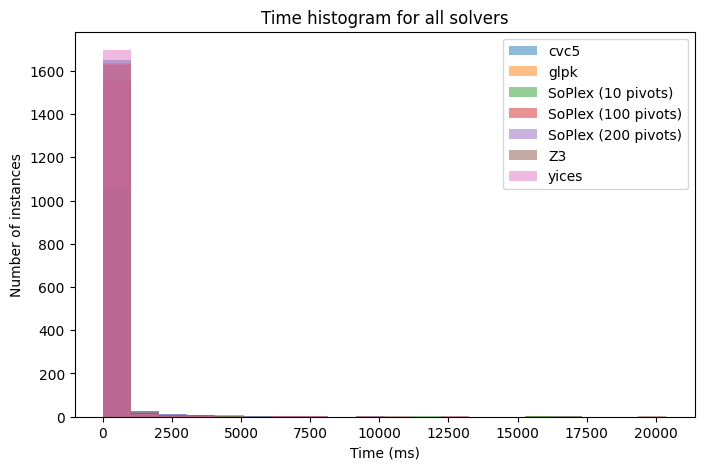

In [311]:
plot_time_histogram(*profile_results, title="Time histogram for all solvers", fixed_min_bin=0)

In [312]:
len(set(soplex_i100[soplex_i100["theory::arith::z::arith::relax::calls"] > 0].index)
    | set(soplex_i200[soplex_i200["theory::arith::z::arith::relax::calls"] > 0].index))

240

In [313]:
query_time(*profile_results, instances=("0028-labyrinth-12-0.smt2", "0075-labyrinth-13-0.smt2"))

,cvc5,glpk,SoPlex (10 pivots),SoPlex (100 pivots),SoPlex (200 pivots),Z3,yices
0028-labyrinth-12-0.smt2,36.900,29.747,24.467,29.919,35.621,3.57,2.888
0075-labyrinth-13-0.smt2,122.582,106.315,36.765,107.315,119.387,8.40,321.847


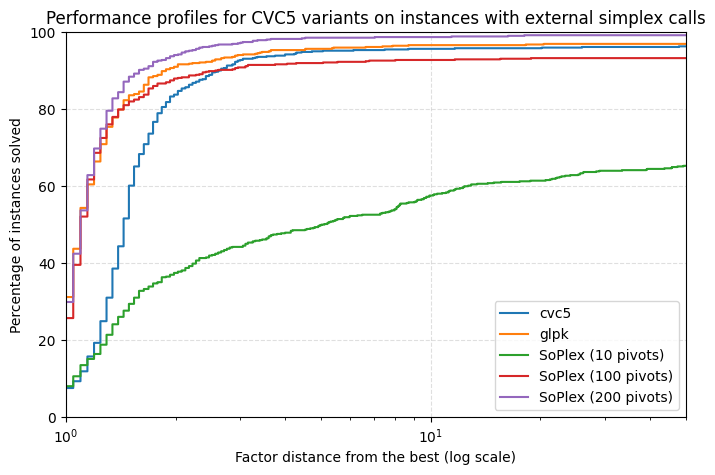

In [314]:
ax, fig = plot_performance_profiles(
    *external_cvc5_variants__results,
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=50,
    # metric_add=0.001,
    title="Performance profiles for CVC5 variants on instances with external simplex calls",
)
# Save the figure for latex paper
ax.get_figure().savefig("cvc5_external_simplex_calls.pdf", bbox_inches="tight")

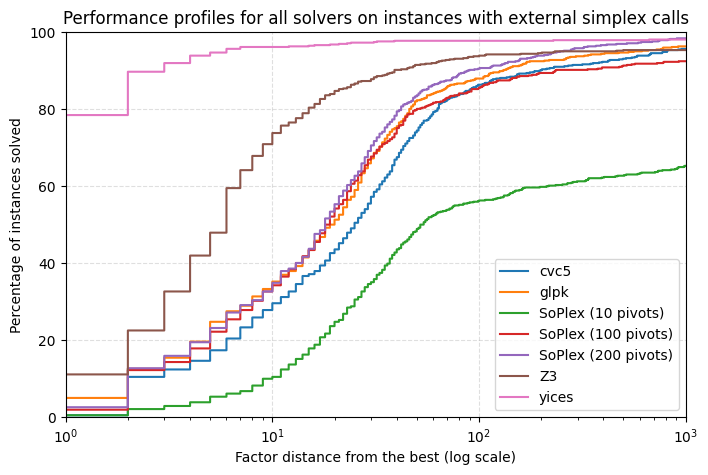

In [315]:
ax, fig = plot_performance_profiles(
    *external_profile_results,
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
    metric_add=0.001,
    title="Performance profiles for all solvers on instances with external simplex calls",
)
ax.get_figure().savefig("all_external_simplex_calls.pdf", bbox_inches="tight")

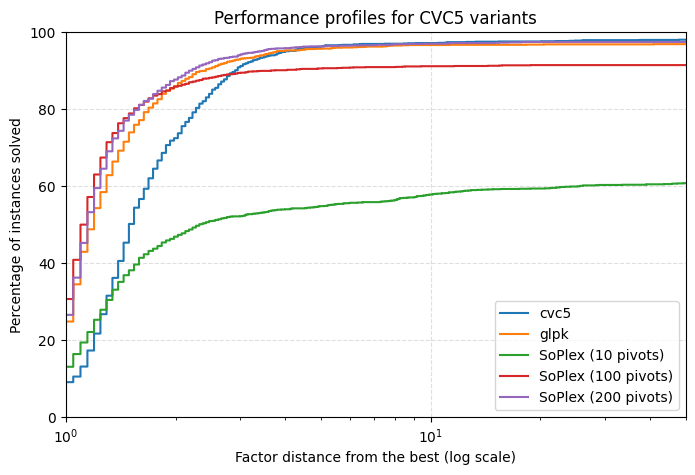

In [316]:
ax, fig = plot_performance_profiles(
    *cvc5_variants_results,
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=50,
    metric_add=0.001,
    title="Performance profiles for CVC5 variants",
)

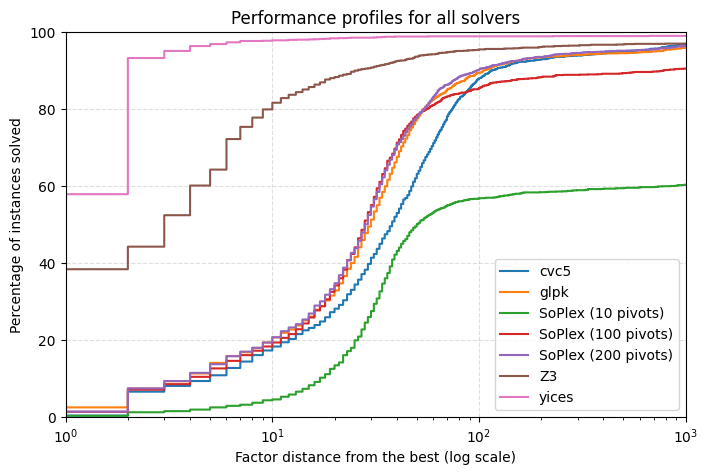

In [317]:
ax, fig = plot_performance_profiles(
    *profile_results,
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
    metric_add=0.001,
    title="Performance profiles for all solvers",
)